In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense, Dropout

In [2]:
train_path = r"C:\Users\Apex-pc\Downloads\alzheimers-detection-ai\Alzheimer_s Dataset\train"
test_path = r"C:\Users\Apex-pc\Downloads\alzheimers-detection-ai\Alzheimer_s Dataset\test"

In [3]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

test_datagen = ImageDataGenerator(
    rescale=1./255
)

train_data = train_datagen.flow_from_directory(
    train_path,
    target_size=(150,150),
    batch_size=32,
    class_mode='categorical'
)

test_data = test_datagen.flow_from_directory(
    test_path,
    target_size=(150,150),
    batch_size=32,
    class_mode='categorical'
)

Found 6400 images belonging to 4 classes.
Found 6400 images belonging to 4 classes.


In [4]:
model = Sequential()

model.add(Conv2D(150, (3,3), activation='relu', input_shape=(150,150,3)))
model.add(MaxPooling2D(pool_size=(2,2)))

model.add(Conv2D(64, (3,3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))

model.add(Conv2D(128, (3,3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))

model.add(Flatten())

model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(4, activation='softmax'))

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

C:\Users\Apex-pc\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 150)  │         4,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 150)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        86,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 36992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     4,735,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,900,140 (18.69 MB)

 Trainable params: 4,900,140 (18.69 MB)

 Non-trainable params: 0 (0.00 B)

In [5]:
history = model.fit(
    train_data,
    validation_data=test_data,
    epochs=10
)

Epoch 1/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 290s 1s/step - accuracy: 0.4873 - loss: 1.0722 - val_accuracy: 0.5000 - val_loss: 1.0269
Epoch 2/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 295s 1s/step - accuracy: 0.5155 - loss: 0.9999 - val_accuracy: 0.5033 - val_loss: 0.9446
Epoch 3/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 306s 2s/step - accuracy: 0.5280 - loss: 0.9540 - val_accuracy: 0.5627 - val_loss: 0.8957
Epoch 4/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 356s 2s/step - accuracy: 0.5448 - loss: 0.9387 - val_accuracy: 0.5612 - val_loss: 0.9048
Epoch 5/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 373s 2s/step - accuracy: 0.5512 - loss: 0.9271 - val_accuracy: 0.5700 - val_loss: 0.8824
Epoch 6/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 373s 2s/step - accuracy: 0.5528 - loss: 0.9237 - val_accuracy: 0.5477 - val_loss: 0.9136
Epoch 7/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 365s 2s/step - accuracy: 0.5484 - loss: 0.9160 - val_accuracy: 0.5708 - val_loss: 0.8645
Epoch 8/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 321s 2s/step - accuracy: 0.5539 - loss: 0.9032 - val_accu

In [8]:
model.save("alzheimer_model.h5")

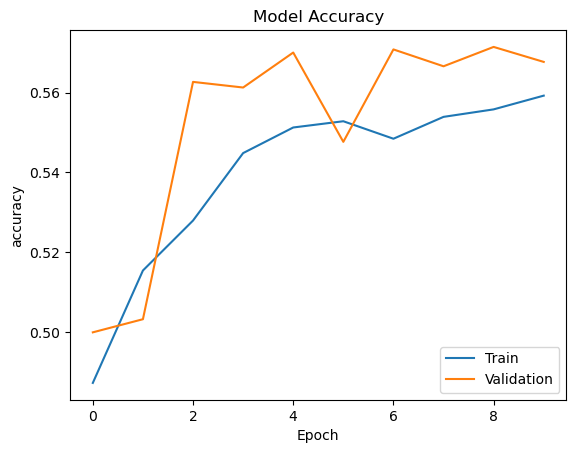

In [9]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title('Model Accuracy')
plt.ylabel('accuracy')
plt.xlabel('Epoch')

plt.legend(['Train', 'Validation'])

plt.show()